## Employee Attrition Prediction Dataset

1. No null values in this dataset
2. There are 6 string attributes in this dataset.
    - All these values contain classes meaning they should be turned into seperate classes per attribute.
    - for example `YES` -> 1 & `No` -> 0 (binary classification) or using -1 and 1.

In [6]:
import pandas as pd

df = pd.read_csv("../data/employee_attrition_dataset_10000.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    10000 non-null  int64
 1   Age                            10000 non-null  int64
 2   Gender                         10000 non-null  str  
 3   Marital_Status                 10000 non-null  str  
 4   Department                     10000 non-null  str  
 5   Job_Role                       10000 non-null  str  
 6   Job_Level                      10000 non-null  int64
 7   Monthly_Income                 10000 non-null  int64
 8   Hourly_Rate                    10000 non-null  int64
 9   Years_at_Company               10000 non-null  int64
 10  Years_in_Current_Role          10000 non-null  int64
 11  Years_Since_Last_Promotion     10000 non-null  int64
 12  Work_Life_Balance              10000 non-null  int64
 13  Job_Satisfaction            

### Scaling 

This dataset obviously need scaling, `Monthly_Income` values are very large compared to over integer attributes


In [ ]:
print(f"MAX: {df["Monthly_Income"].max()} | MIN: {df["Monthly_Income"].min()}")

MAX: 19999 | MIN: 3000


In [9]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


### String Data Types

There are 6 datatypes and they are:
- Gender
- Marital_Status
- Department
- Job_Role
- Overtime
- Attrition

In [14]:
string_df = df.select_dtypes(include=["str"])
print(f"The string attributes in this dataset are: \n{string_df.head()}")

The string attributes in this dataset are: 
   Gender Marital_Status Department   Job_Role Overtime Attrition
0    Male         Single    Finance    Manager       No        No
1  Female       Divorced         HR  Assistant      Yes        No
2  Female        Married  Marketing    Manager      Yes       Yes
3  Female       Divorced         HR    Manager       No        No
4    Male        Married         HR    Analyst       No        No


In [ ]:
df.index = df["Employee_ID"]
df = df.drop(columns=["Employee_ID"])
df.head()

# OR set_index can be used
# df = df.set_index("Employee_ID")

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
Employee_ID,,,,,,,,,,,,,,,,,,,,,
1,58,Male,Single,Finance,Manager,5,7332,81,24,12,...,No,9,48,16,4,1,1,49,3,No
2,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,...,Yes,9,57,10,4,1,1,25,1,No
3,34,Female,Married,Marketing,Manager,4,11485,65,6,4,...,Yes,3,55,1,1,4,3,21,1,Yes
4,27,Female,Divorced,HR,Manager,4,18707,28,12,9,...,No,9,53,2,3,4,1,46,2,No
5,40,Male,Married,HR,Analyst,1,16398,92,3,9,...,No,1,54,11,1,1,1,43,4,No


In [26]:
numeric_df = df.select_dtypes(include=["int64"])
numeric_df.head()

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
Employee_ID,,,,,,,,,,,,,,,,,,,
1,58,5,7332,81,24,12,3,1,3,2,74,9,48,16,4,1,1,49,3
2,48,4,6069,55,18,7,5,1,2,2,24,9,57,10,4,1,1,25,1
3,34,4,11485,65,6,4,3,4,5,1,63,3,55,1,1,4,3,21,1
4,27,4,18707,28,12,9,1,1,1,2,4,9,53,2,3,4,1,46,2
5,40,1,16398,92,3,9,1,3,4,3,62,1,54,11,1,1,1,43,4


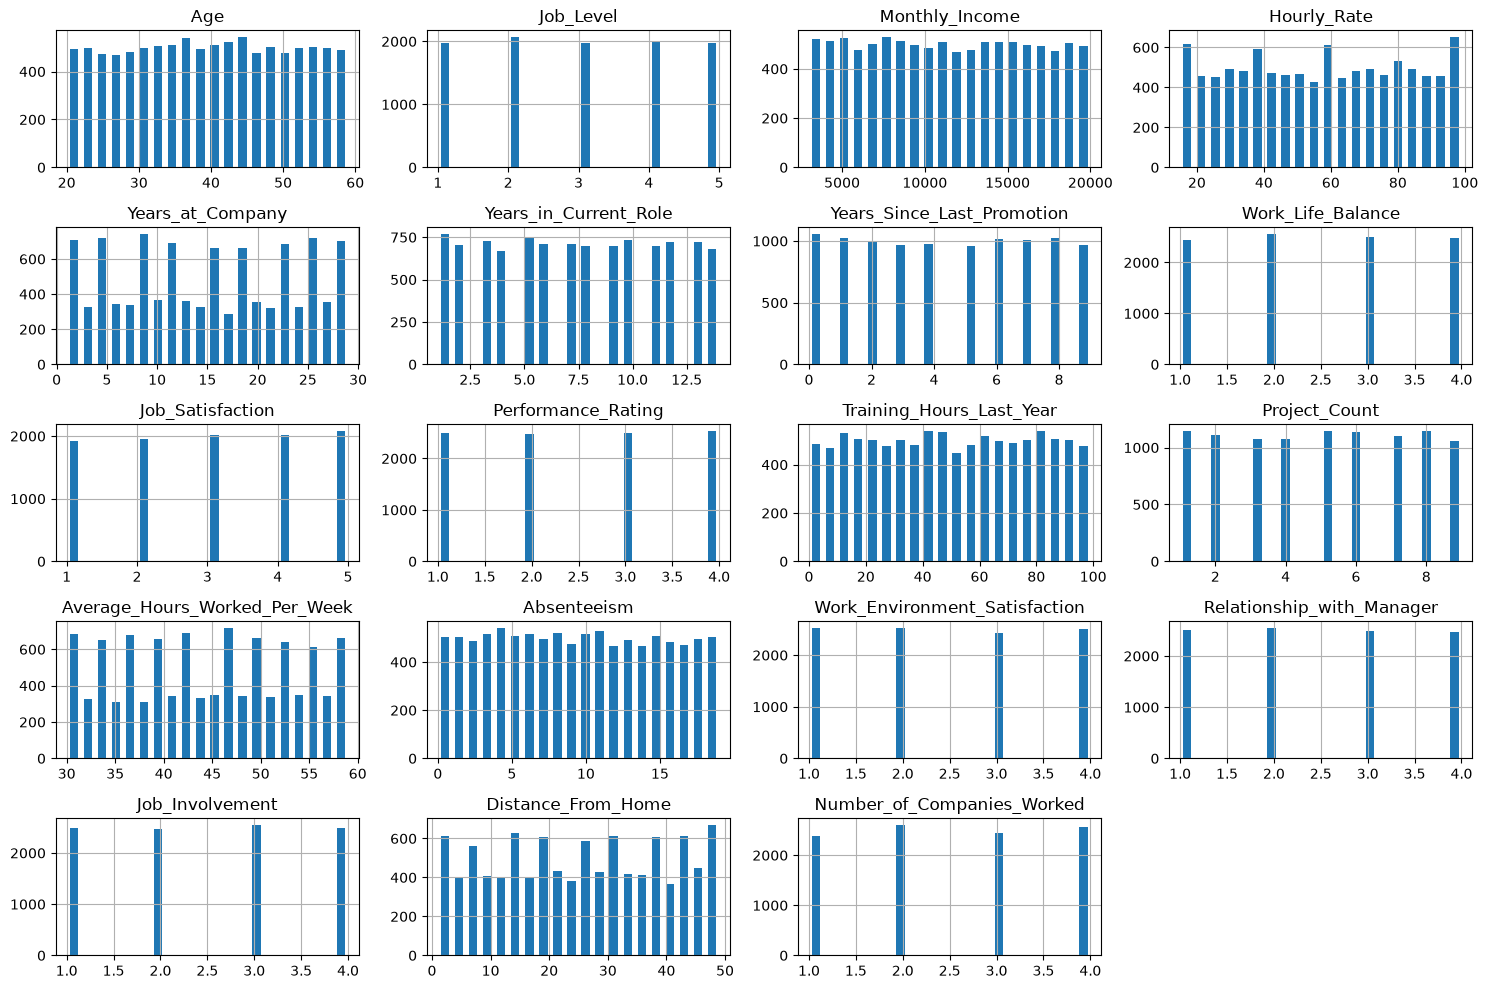

In [35]:
import matplotlib.pyplot as plt
numeric_df.hist(figsize=(15, 10), bins=20, rwidth=0.6)
plt.tight_layout()
plt.show();

In [37]:
print(f"Number of rows and columns:", df.shape)

Number of rows and columns: (10000, 26)


# Data preperation and Cleaning


In [38]:
print(df.isnull().sum())

Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
AttritionBinary                  0
dtype: int64


In [39]:
# Identify invalid data 
invalid_ages = df[df["Age"] < 0]
print(invalid_ages)

Empty DataFrame
Columns: [Age, Gender, Marital_Status, Department, Job_Role, Job_Level, Monthly_Income, Hourly_Rate, Years_at_Company, Years_in_Current_Role, Years_Since_Last_Promotion, Work_Life_Balance, Job_Satisfaction, Performance_Rating, Training_Hours_Last_Year, Overtime, Project_Count, Average_Hours_Worked_Per_Week, Absenteeism, Work_Environment_Satisfaction, Relationship_with_Manager, Job_Involvement, Distance_From_Home, Number_of_Companies_Worked, Attrition, AttritionBinary]
Index: []

[0 rows x 26 columns]
